<a href="https://colab.research.google.com/github/Thangapandi1611/ml-safety-project/blob/main/week7/Occulation_Vehicle_night_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
#Packages load
import torch
import torch.nn as nn

from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd
from PIL import Image
import os

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [4]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [5]:
#Vehicle model
MODEL_PATH= '/content/drive/MyDrive/MLS_DATA/Vehicle_model.pth'

In [6]:
model = models.resnet18(weights=None)

model.fc = nn.Linear(
    model.fc.in_features,
    1
)

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model.to(device)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [12]:
#Night data
DATASET_PATH="/content/drive/MyDrive/MLS_DATA/test-night"

In [8]:
#Transform the image
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [15]:
class CarlaDataset(Dataset):

    def __init__(self, data_path, label_column, transform=None):

        self.data_path = data_path
        self.transform = transform

        self.labels = pd.read_csv(
            os.path.join(data_path, "labels.csv")
        )

        self.label_column = label_column

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        row = self.labels.iloc[idx]

        frame = str(row['frame']).zfill(6)

        img_path = os.path.join(
            self.data_path,
            "rgb-front",
            f"{frame}.jpg"
        )

        image = Image.open(img_path).convert("RGB")

        label = int(row[self.label_column])

        if self.transform:
            image = self.transform(image)

        return image, label

In [16]:
#Evaluation function
def evaluate_model(model_file, label_column,test_path):

    # Create dataset
    val_dataset = CarlaDataset(
        test_path,
        label_column=label_column,
        transform=transform
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False
    )

    # Create model
    model = models.resnet18(pretrained=True)

    model.fc = nn.Linear(
        model.fc.in_features,
        1
    )

    # Load weights
    model.load_state_dict(
        torch.load(model_file, map_location=device)
    )

    model = model.to(device)

    model.eval()

    # Prediction lists
    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels_batch in val_loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs)

            preds = (probs > 0.5).int()

            all_preds.extend(preds.cpu().numpy())

            all_labels.extend(labels_batch.numpy())


    # Flatten predictions
    all_preds = [p[0] for p in all_preds]

    # Metrics
    cm = confusion_matrix(all_labels, all_preds)
    accuracy = accuracy_score(all_labels, all_preds)

    precision = precision_score(all_labels, all_preds)

    recall = recall_score(all_labels, all_preds)

    f1 = f1_score(all_labels, all_preds)

    return accuracy, precision, recall, f1, cm

In [17]:
Evaluation_night=evaluate_model(MODEL_PATH,"has_pedestrian",DATASET_PATH)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 147MB/s]


In [18]:
Evaluation_night

(0.6588888888888889,
 0.16844919786096257,
 0.1721311475409836,
 0.17027027027027028,
 array([[2246,  622],
        [ 606,  126]]))

In [20]:
#Occlusion Function
def occlusion_heatmap(image,model,transform,device,patch_size=32,stride=16):
    import numpy as np
    from PIL import Image
    import torch

    # Convert image to numpy array
    img_np = np.array(image)

    H, W, _ = img_np.shape

    # Store importance scores
    heatmap = np.zeros((H, W))

    # Original prediction
    img_tensor = transform(image)
    img_tensor = img_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        original_score = torch.sigmoid(
            model(img_tensor)
        ).item()

    # Slide occlusion window
    for y in range(0, H - patch_size, stride):

        for x in range(0, W - patch_size, stride):

            # Create copy
            occluded = img_np.copy()

            # Hide region
            occluded[
                y:y+patch_size,
                x:x+patch_size
            ] = 0

            # Convert back to image
            occ_img = Image.fromarray(occluded)

            # Preprocess
            occ_tensor = transform(occ_img)
            occ_tensor = occ_tensor.unsqueeze(0).to(device)

            # Predict again
            with torch.no_grad():

                score = torch.sigmoid(
                    model(occ_tensor)
                ).item()

            # Importance
            importance = original_score - score

            # Store score
            heatmap[
                y:y+patch_size,
                x:x+patch_size
            ] += importance

    # Normalize
    heatmap -= heatmap.min()

    heatmap /= (
        heatmap.max() + 1e-8
    )

    return heatmap


In [21]:
dataset = CarlaDataset(
    DATASET_PATH,
    label_column="has_pedestrian",
    transform=transform
)

In [32]:
#Separating correct/ wrong Predictions
correct_images = []
wrong_images = []

with torch.no_grad():

    for idx in range(len(dataset)):

        image, label = dataset[idx]

        image_tensor = (
            image
            .unsqueeze(0)
            .to(device)
        )

        output = model(image_tensor)

        prob = torch.sigmoid(output)

        pred = (
            prob > 0.5
        ).float().item()

        row = dataset.labels.iloc[idx]

        frame = str(
            row['frame']
        ).zfill(6)

        img_path = os.path.join(
            dataset.data_path,
            "rgb-front",
            f"{frame}.jpg"
        )

        if pred == label:

            correct_images.append(
                (img_path, label)
            )

        else:

            wrong_images.append(
                (img_path, label)
            )

In [33]:
print(
    "Correct:",
    len(correct_images)
)

print(
    "Wrong:",
    len(wrong_images)
)

Correct: 2372
Wrong: 1228


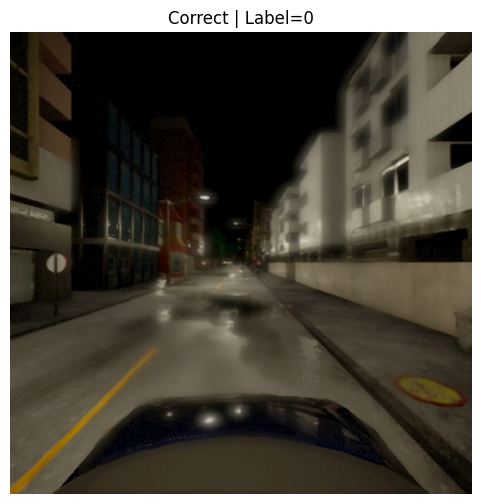

In [35]:
#Display a Correct Example
img_path, label = correct_images[0]

image = Image.open(
    img_path
).convert("RGB")

plt.figure(figsize=(6,6))

plt.imshow(image)

plt.title(
    f"Correct | Label={label}"
)

plt.axis("off")

plt.show()

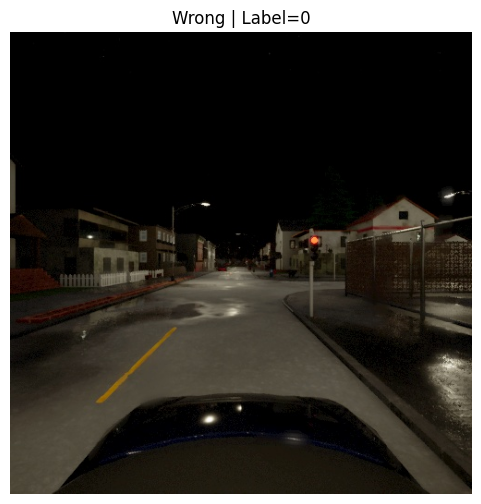

In [36]:
#Display wrong image example
img_path, label = wrong_images[0]

image = Image.open(
    img_path
).convert("RGB")

plt.figure(figsize=(6,6))

plt.imshow(image)

plt.title(
    f"Wrong | Label={label}"
)

plt.axis("off")

plt.show()

In [37]:
#Generate occlusion map
img_path, label = correct_images[0]

image = Image.open(
    img_path
).convert("RGB")

heatmap = occlusion_heatmap(
    image,
    model,
    transform,
    device
)

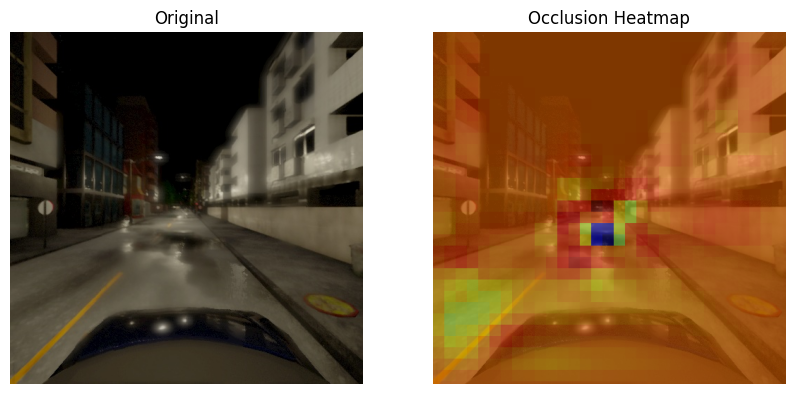

In [38]:
#Heatmaps for correct prediction
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)

plt.imshow(image)

plt.title("Original")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(image)

plt.imshow(
    heatmap,
    cmap="jet",
    alpha=0.5
)

plt.title(
    "Occlusion Heatmap"
)

plt.axis("off")

plt.show()

In [39]:
#Generate occlusion map for wrong prediction
img_path, label =wrong_images[0]

image = Image.open(
    img_path
).convert("RGB")

heatmap = occlusion_heatmap(
    image,
    model,
    transform,
    device
)

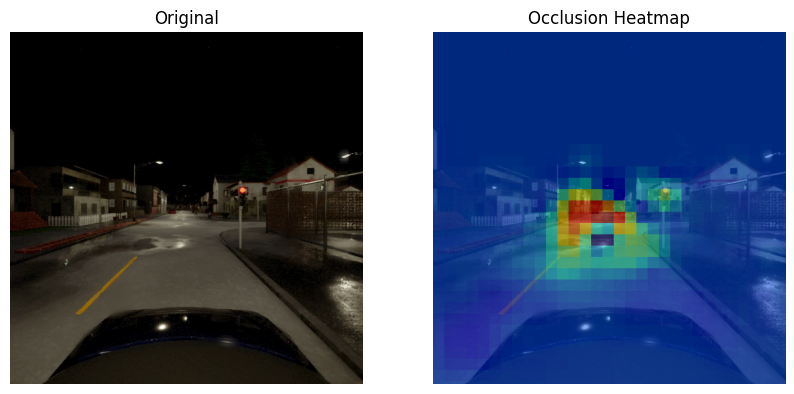

In [40]:
#Heatmaps for wrong prediction
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)

plt.imshow(image)

plt.title("Original")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(image)

plt.imshow(
    heatmap,
    cmap="jet",
    alpha=0.5
)

plt.title(
    "Occlusion Heatmap"
)

plt.axis("off")

plt.show()